# Proof of Concept: Synthetic Fish-Hunger Behavior Classification

**Status: synthetic data only — no real footage or real fish were used here.**

This notebook is a proof of concept for the pipeline described in our proposal,
"Detecting Fish Hunger Levels by Monitoring and Classifying Their Underwater
Swimming Patterns." Since we don't have real underwater footage or a labeled
dataset yet, we simulate fish trajectories with hand-designed behavioral
differences between hunger classes, run them through the same four-feature
extraction pipeline described in the proposal (swimming speed, turning
frequency, vertical position, schooling density), and train a classifier on
top of it.

**What this does and doesn't show:**
-  It demonstrates that the end-to-end pipeline (trajectories → windowed
  features → classifier → Low/Moderate/High) actually runs and produces
  sensible, interpretable results.
-  It does **not** demonstrate real-world accuracy. The synthetic classes
  were deliberately built to differ in speed, turning, depth, and schooling,
  so high accuracy here just confirms the code logic works — it says nothing
  about how separable real hunger states will be from real video. The
  proposal's actual target (macro-F1 ≥ 0.80 on held-out ponds) is the number
  that will matter once we have real data.

Next step once we have a camera and real footage: replace the simulator in
Section 1 with real detection/tracking output, and swap the Random Forest
baseline in Section 4 for the LSTM / CNN-LSTM model described in the proposal.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

np.random.seed(42)
plt.rcParams["figure.facecolor"] = "white"
CLASSES = ["Low", "Moderate", "High"]
COLORS = {"Low": "#4C72B0", "Moderate": "#DD8452", "High": "#C44E52"}
print("Libraries loaded.")


Libraries loaded.


## 1. Simulate synthetic fish trajectories

We simulate three hunger classes (**Low**, **Moderate**, **High**) with
invented behavioral tendencies loosely based on the idea in the proposal:
hungrier fish swim faster, turn more often, drift toward the surface /
feeding zone, and school more tightly. `y = 1` represents the surface.

In [2]:
# --- Simulation parameters per hunger class ---
# These are *invented* behavioral tendencies, loosely inspired by the idea that
# hungrier fish swim faster, turn more, rise toward the surface/feeding zone,
# and school more tightly. They exist only to generate a plausible synthetic
# dataset for this proof of concept, not to represent measured biology.
CLASS_PARAMS = {
    "Low":      {"speed_mean": 0.010, "speed_std": 0.004, "turn_noise": 0.18,
                 "surface_pull": 0.000, "cohesion": 0.010},
    "Moderate": {"speed_mean": 0.018, "speed_std": 0.006, "turn_noise": 0.35,
                 "surface_pull": 0.004, "cohesion": 0.030},
    "High":     {"speed_mean": 0.028, "speed_std": 0.008, "turn_noise": 0.55,
                 "surface_pull": 0.010, "cohesion": 0.060},
}

def simulate_session(hunger_class, n_fish=10, n_frames=150, seed=None):
    """Simulate one video 'session': n_fish swimming for n_frames in a
    unit square tank (x: 0-1, y: 0-1, where y=1 is the surface/feeding zone).
    Returns arrays of shape (n_frames, n_fish) for x and y positions.
    """
    rng = np.random.default_rng(seed)
    params = CLASS_PARAMS[hunger_class]

    x = np.zeros((n_frames, n_fish))
    y = np.zeros((n_frames, n_fish))
    heading = rng.uniform(0, 2 * np.pi, n_fish)

    x[0] = rng.uniform(0.1, 0.9, n_fish)
    y[0] = rng.uniform(0.1, 0.9, n_fish)

    for t in range(1, n_frames):
        # random turning
        heading += rng.normal(0, params["turn_noise"], n_fish)

        # pull toward the group centroid (schooling/cohesion)
        cx, cy = x[t - 1].mean(), y[t - 1].mean()
        pull_x = (cx - x[t - 1]) * params["cohesion"]
        pull_y = (cy - y[t - 1]) * params["cohesion"]

        # pull toward the surface/feeding zone (hungrier fish rise more)
        surface_pull = params["surface_pull"]

        speed = np.clip(rng.normal(params["speed_mean"], params["speed_std"], n_fish), 0, None)
        dx = speed * np.cos(heading) + pull_x
        dy = speed * np.sin(heading) + pull_y + surface_pull

        x[t] = np.clip(x[t - 1] + dx, 0, 1)
        y[t] = np.clip(y[t - 1] + dy, 0, 1)

    return x, y


def simulate_dataset(n_sessions_per_class=40, n_fish=10, n_frames=150):
    """Simulate many sessions across all three classes."""
    sessions = []
    seed_counter = 0
    for cls in CLASSES:
        for s in range(n_sessions_per_class):
            x, y = simulate_session(cls, n_fish=n_fish, n_frames=n_frames, seed=seed_counter)
            sessions.append({"class": cls, "session_id": f"{cls}_{s:03d}", "x": x, "y": y})
            seed_counter += 1
    return sessions

sessions = simulate_dataset(n_sessions_per_class=40, n_fish=10, n_frames=150)
print(f"Simulated {len(sessions)} sessions across {len(CLASSES)} hunger classes.")


Simulated 120 sessions across 3 hunger classes.


A quick visual sanity check — one example session per class:

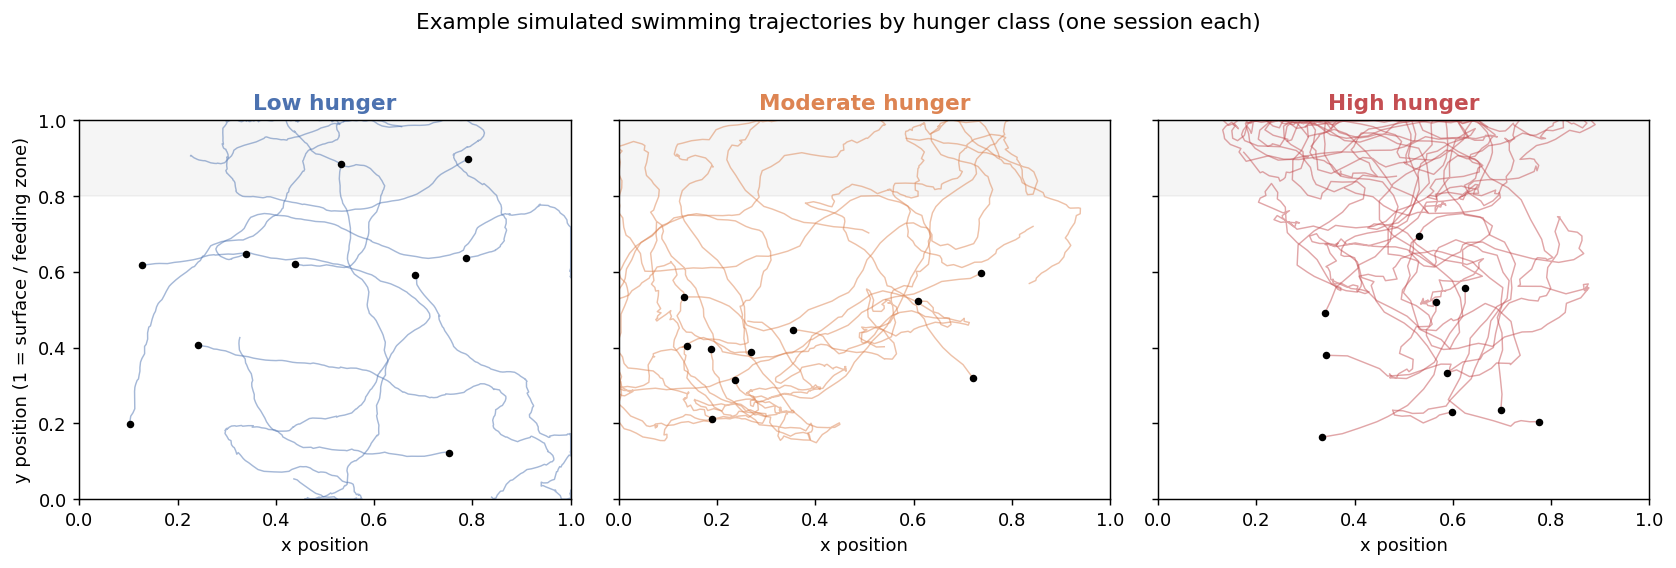

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharex=True, sharey=True)

for ax, cls in zip(axes, CLASSES):
    example = next(s for s in sessions if s["class"] == cls)
    x, y = example["x"], example["y"]
    n_fish = x.shape[1]
    for f in range(n_fish):
        ax.plot(x[:, f], y[:, f], alpha=0.5, linewidth=0.8, color=COLORS[cls])
    ax.scatter(x[0], y[0], color="black", s=10, zorder=5, label="start")
    ax.axhspan(0.8, 1.0, color="gray", alpha=0.08)  # surface/feeding zone
    ax.set_title(f"{cls} hunger", color=COLORS[cls], fontweight="bold")
    ax.set_xlabel("x position")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

axes[0].set_ylabel("y position (1 = surface / feeding zone)")
fig.suptitle("Example simulated swimming trajectories by hunger class (one session each)", y=1.03)
plt.tight_layout()
plt.savefig("fig_trajectories.png", dpi=130, bbox_inches="tight")
plt.show()


## 2. Feature extraction

For each session, we slide a window across the trajectories and compute the
same four features named in the proposal, aggregated per window:

- **Swimming speed** — median frame-to-frame displacement of all fish
- **Turning frequency** — fraction of frames where heading change exceeds a threshold
- **Vertical position** — mean normalized depth (1 = surface / feeding zone)
- **Schooling density** — mean nearest-neighbor distance (lower = tighter schooling)

In [4]:
def extract_window_features(x_win, y_win, turn_threshold=0.35, dt=1.0):
    """Compute the four behavioral features for one window of shape
    (window_len, n_fish), matching the indicators described in the proposal:
    swimming speed, turning frequency, vertical position, schooling density.
    """
    n_frames, n_fish = x_win.shape

    # --- Swimming speed: median per-frame displacement / dt, across fish ---
    dx = np.diff(x_win, axis=0)
    dy = np.diff(y_win, axis=0)
    speed = np.sqrt(dx**2 + dy**2) / dt          # shape: (n_frames-1, n_fish)
    speed_feature = np.median(speed)

    # --- Turning frequency: fraction of frames where heading change
    #     exceeds a threshold, averaged across fish ---
    heading = np.arctan2(dy, dx)
    dtheta = np.diff(heading, axis=0)
    dtheta = (dtheta + np.pi) % (2 * np.pi) - np.pi   # wrap to [-pi, pi]
    turns = np.abs(dtheta) > turn_threshold
    turn_feature = turns.mean()

    # --- Vertical position: mean normalized depth across the window ---
    vertical_feature = y_win.mean()

    # --- Schooling density: mean nearest-neighbor distance per frame,
    #     averaged over the window (lower = more tightly schooled) ---
    nn_dists = []
    for t in range(n_frames):
        pts = np.stack([x_win[t], y_win[t]], axis=1)
        if n_fish > 1:
            d = np.sqrt(((pts[:, None, :] - pts[None, :, :]) ** 2).sum(-1))
            np.fill_diagonal(d, np.inf)
            nn_dists.append(d.min(axis=1).mean())
    schooling_feature = np.mean(nn_dists) if nn_dists else np.nan

    return speed_feature, turn_feature, vertical_feature, schooling_feature


def build_feature_dataset(sessions, window_len=15):
    rows = []
    for sess in sessions:
        x, y = sess["x"], sess["y"]
        n_frames = x.shape[0]
        n_windows = n_frames // window_len
        for w in range(n_windows):
            sl = slice(w * window_len, (w + 1) * window_len)
            speed, turn, vpos, school = extract_window_features(x[sl], y[sl])
            rows.append({
                "session_id": sess["session_id"],
                "class": sess["class"],
                "window": w,
                "speed": speed,
                "turning_frequency": turn,
                "vertical_position": vpos,
                "schooling_nn_distance": school,
            })
    return pd.DataFrame(rows)

features_df = build_feature_dataset(sessions, window_len=15)
print(f"Feature table: {features_df.shape[0]} windows x {features_df.shape[1]} columns")
features_df.head()


Feature table: 1200 windows x 7 columns


,session_id,class,window,speed,turning_frequency,vertical_position,schooling_nn_distance
0,Low_000,Low,0,0.010650,0.176923,0.549237,0.190302
1,Low_000,Low,1,0.010124,0.176923,0.556233,0.176253
2,Low_000,Low,2,0.008424,0.176923,0.572250,0.170985
3,Low_000,Low,3,0.008101,0.353846,0.562532,0.170386
4,Low_000,Low,4,0.007326,0.430769,0.553966,0.199728


## 3. Explore the synthetic dataset\n\nDo the four features actually separate by class, the way we designed them to?

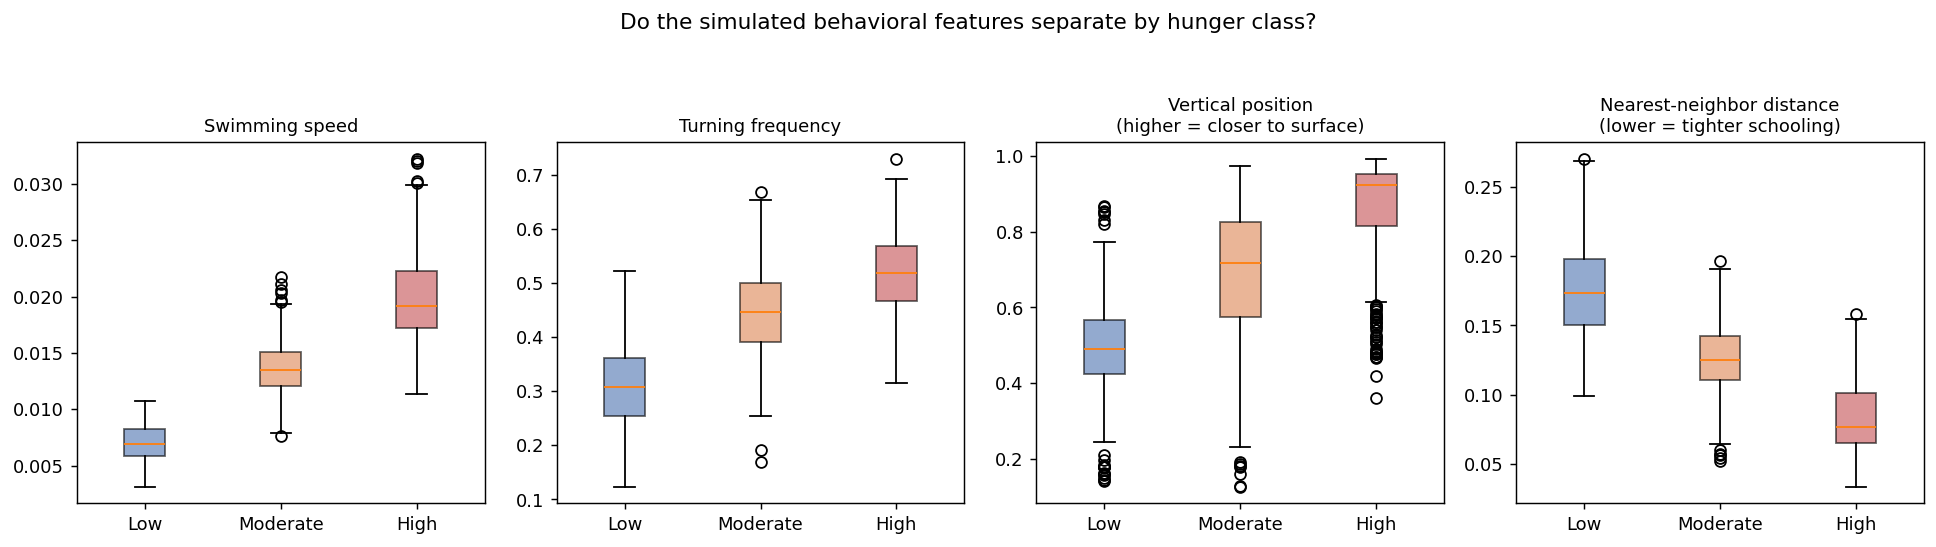

In [5]:
feature_cols = ["speed", "turning_frequency", "vertical_position", "schooling_nn_distance"]
pretty_names = {
    "speed": "Swimming speed",
    "turning_frequency": "Turning frequency",
    "vertical_position": "Vertical position\n(higher = closer to surface)",
    "schooling_nn_distance": "Nearest-neighbor distance\n(lower = tighter schooling)",
}

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, col in zip(axes, feature_cols):
    data = [features_df.loc[features_df["class"] == c, col] for c in CLASSES]
    bp = ax.boxplot(data, labels=CLASSES, patch_artist=True)
    for patch, cls in zip(bp["boxes"], CLASSES):
        patch.set_facecolor(COLORS[cls])
        patch.set_alpha(0.6)
    ax.set_title(pretty_names[col], fontsize=10)
    ax.tick_params(axis="x", rotation=0)

fig.suptitle("Do the simulated behavioral features separate by hunger class?", y=1.04)
plt.tight_layout()
plt.savefig("fig_boxplots.png", dpi=130, bbox_inches="tight")
plt.show()


## 4. Train a classifier

We split by **session**, not by window, so that windows from the same
simulated session never appear in both train and test — mirroring the
"leakage-safe" pond-wise split described in the proposal's methodology.

For this proof of concept we use a Random Forest on the aggregated window
features as a lightweight baseline. The real pipeline calls for testing this
kind of baseline *against* an LSTM / CNN-LSTM on the raw temporal sequences,
exactly as described in the proposal — that comparison needs real sequential
data to be meaningful, so it isn't reproduced here.

In [6]:
# Split by session (not by window) so that windows from the same simulated
# session never appear in both train and test - the same "leakage-safe"
# principle the real pipeline will use when splitting by pond/recording date.
session_ids = features_df["session_id"].unique()
train_ids, test_ids = train_test_split(session_ids, test_size=0.25, random_state=42)

train_df = features_df[features_df["session_id"].isin(train_ids)]
test_df = features_df[features_df["session_id"].isin(test_ids)]

X_train, y_train = train_df[feature_cols], train_df["class"]
X_test, y_test = test_df[feature_cols], test_df["class"]

clf = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Train windows: {len(X_train)}  |  Test windows: {len(X_test)}")
print(f"Test accuracy: {acc:.2%}\n")
print(classification_report(y_test, y_pred))


Train windows: 900  |  Test windows: 300
Test accuracy: 98.67%

              precision    recall  f1-score   support

        High       0.96      1.00      0.98        80
         Low       0.99      1.00      1.00       100
    Moderate       1.00      0.97      0.98       120

    accuracy                           0.99       300
   macro avg       0.98      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



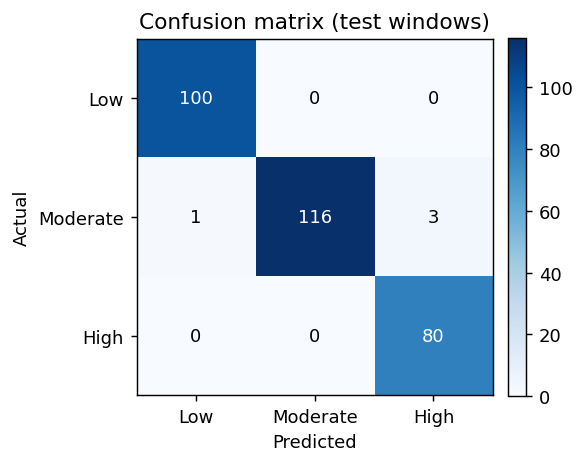

In [7]:
cm = confusion_matrix(y_test, y_pred, labels=CLASSES)

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CLASSES)))
ax.set_yticks(range(len(CLASSES)))
ax.set_xticklabels(CLASSES)
ax.set_yticklabels(CLASSES)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion matrix (test windows)")

for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig("fig_confusion.png", dpi=130, bbox_inches="tight")
plt.show()


## 5. Feature importance (RQ1)

The proposal's first research question asks which behavioral cue carries the
strongest hunger signal. Here's what the Random Forest picked up on on the
*synthetic* data — in the real dataset this is genuinely an open question,
not something we're assuming the answer to.

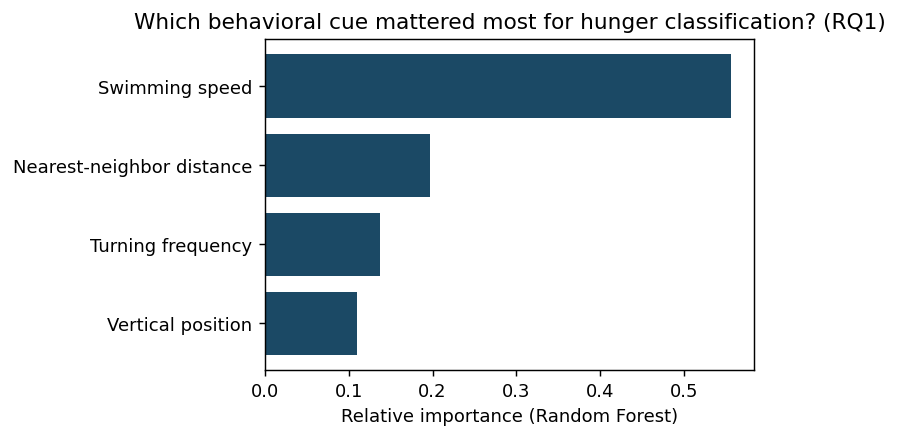

speed                    0.556033
schooling_nn_distance    0.197200
turning_frequency        0.137461
vertical_position        0.109306
dtype: float64

In [8]:
importances = pd.Series(clf.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.barh(
    [pretty_names[c].split("\n")[0] for c in importances.index],
    importances.values,
    color="#1B4965",
)
ax.set_xlabel("Relative importance (Random Forest)")
ax.set_title("Which behavioral cue mattered most for hunger classification? (RQ1)")
plt.tight_layout()
plt.savefig("fig_importance.png", dpi=130, bbox_inches="tight")
plt.show()

importances.sort_values(ascending=False)


## 6. Next steps

- Replace `simulate_session()` with real detection + tracking output from
  underwater video (see the proposal's Methodology section).
- Rebuild this dataset from real labeled clips (Low / Moderate / High, based
  on time since last feeding + observed feeding response).
- Swap the Random Forest baseline for an LSTM / CNN-LSTM on raw feature
  sequences, and keep the Random Forest around as a baseline to check whether
  the temporal model is actually earning its added complexity.
- Re-run the pond-wise (not window-wise) split on real sessions, and report
  macro-F1 and a confusion matrix the same way we did here.

This notebook is meant to be a living file — as real data comes in, the
synthetic simulator in Section 1 is the piece that gets replaced first.